In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pyprojroot import here

In [2]:
RAW_DATA_DIR = here() / "data" / "raw"
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results" 

In [3]:
with open(PROCESSED_DATA_DIR/'plot_summary.json') as f:
    plot_data = json.load(f)

with open(PROCESSED_DATA_DIR/'stats_table.json') as f:
    import json
    stats_rows = json.load(f)

sig_years = {str(r['year']) for r in stats_rows if r['significant']}

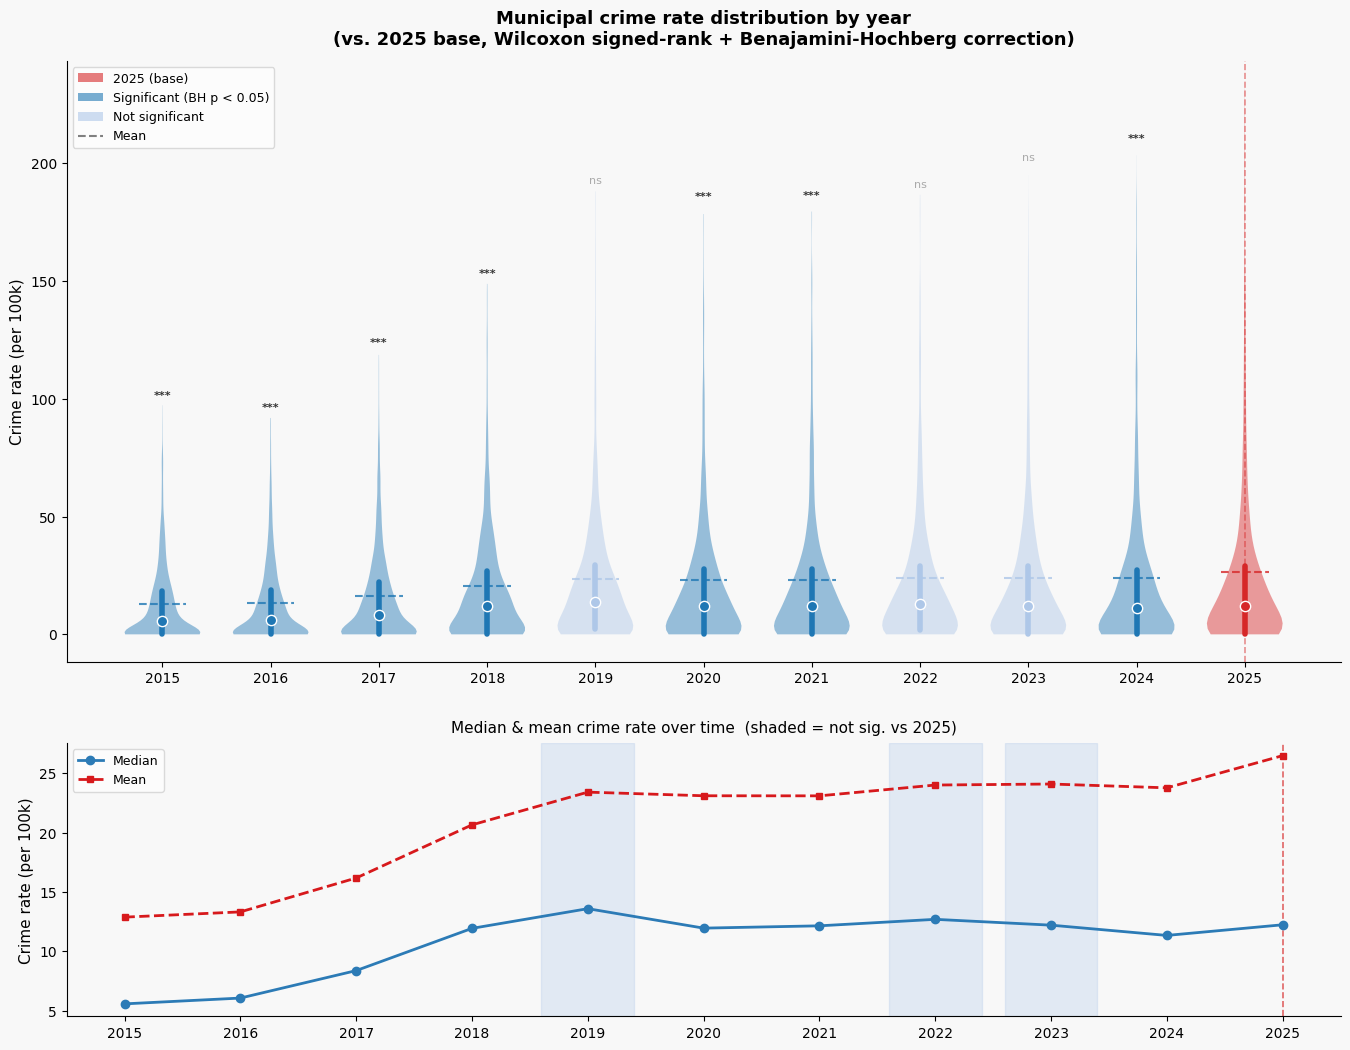

In [4]:
years_ordered = [str(y) for y in range(2015, 2026)]
colors = ['#d62728' if yr == '2025' else
          '#1f77b4' if yr in sig_years else
          '#aec7e8'
          for yr in years_ordered]

fig, axes = plt.subplots(2, 1, figsize=(14, 11),
                         gridspec_kw={'height_ratios': [2.2, 1]})
fig.patch.set_facecolor('#f8f8f8')

ax1 = axes[0]
ax1.set_facecolor('#f8f8f8')

positions = np.arange(len(years_ordered))

for i, yr in enumerate(years_ordered):
    d = plot_data[yr]
    raw = np.array(d['raw'])

    # Violin
    parts = ax1.violinplot(raw, positions=[i], widths=0.7,
                           showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.45)
        pc.set_edgecolor('none')

    # IQR box
    ax1.plot([i, i], [d['q25'], d['q75']], color=colors[i], linewidth=4, solid_capstyle='round')
    # Median dot
    ax1.scatter(i, d['q50'], color=colors[i], s=55, zorder=5, edgecolors='white', linewidths=1)
    # Mean dash
    ax1.hlines(d['mean'], i - 0.22, i + 0.22, colors=colors[i],
               linewidths=1.5, linestyles='dashed', alpha=0.8)

    # Significance annotation
    if yr != '2025':
        sig = yr in sig_years
        label = '***' if sig else 'ns'
        col   = '#333333' if sig else '#aaaaaa'
        ax1.text(i, d['q99'] + 2, label, ha='center', va='bottom',
                 fontsize=8, color=col, fontweight='bold' if sig else 'normal')

ax1.set_xticks(positions)
ax1.set_xticklabels(years_ordered, fontsize=10)
ax1.set_ylabel('Crime rate (per 100k)', fontsize=11)
ax1.set_title('Municipal crime rate distribution by year\n(vs. 2025 base, Wilcoxon signed-rank + Benajamini-Hochberg correction)',
              fontsize=13, fontweight='bold', pad=12)
ax1.spines[['top','right']].set_visible(False)
ax1.axvline(x=10, color='#d62728', linewidth=1.2, linestyle='--', alpha=0.5)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#d62728', alpha=0.6, label='2025 (base)'),
    mpatches.Patch(facecolor='#1f77b4', alpha=0.6, label='Significant (BH p < 0.05)'),
    mpatches.Patch(facecolor='#aec7e8', alpha=0.6, label='Not significant'),
    plt.Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label='Mean'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.7)

# ── Panel 2: Median + mean over time ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#f8f8f8')

medians = [plot_data[yr]['q50'] for yr in years_ordered]
means   = [plot_data[yr]['mean'] for yr in years_ordered]

ax2.plot(positions, medians, marker='o', color='#2c7bb6', linewidth=2,
         markersize=6, label='Median', zorder=3)
ax2.plot(positions, means, marker='s', color='#d7191c', linewidth=2,
         linestyle='--', markersize=5, label='Mean', zorder=3)

# Shade non-significant years
non_sig = [i for i, yr in enumerate(years_ordered) if yr not in sig_years and yr != '2025']
for i in non_sig:
    ax2.axvspan(i - 0.4, i + 0.4, color='#aec7e8', alpha=0.3)

ax2.set_xticks(positions)
ax2.set_xticklabels(years_ordered, fontsize=10)
ax2.set_ylabel('Crime rate (per 100k)', fontsize=11)
ax2.set_title('Median & mean crime rate over time  (shaded = not sig. vs 2025)',
              fontsize=11, pad=8)
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=9, framealpha=0.7)
ax2.axvline(x=10, color='#d62728', linewidth=1.2, linestyle='--', alpha=0.7)

plt.tight_layout(pad=2.5)
plt.savefig(RESULTS_DATA_DIR/'graphs/inferential/crime_rate_analysis.png', dpi=180, bbox_inches='tight')
plt.show()